In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.7 MB/s eta 0:00:00


In [4]:
import os
from ultralytics import YOLO

# pega as pastas com os caminhos do drive
FOCA = '/content/drive/MyDrive/FOCA_IA'
PASTA_DATASETS = os.path.join(FOCA, 'datasets')
PASTA_MODELS = os.path.join(FOCA, 'models')

print("Encontrou pastas")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Encontrou pastas


Teste para ver a pasta

In [5]:
print(os.listdir('/content/drive/MyDrive/FOCA_IA/models'))

['yolov8_nano_foca', 'yolov8_nano_foca_v2', 'yolov8_nano_foca_v2-2', 'yolov8_nano_foca_v3_800_50e', 'yolov8_nano_foca_v4_AdamW']


Imports necessários aqui

In [6]:
import kagglehub
import os
import yaml
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

Faz o download do dataset do kaggle

In [7]:
print("Iniciando o download do dataset via KaggleHub...")
path = kagglehub.dataset_download("canomercik/wider-face-dataset-for-yolov12-format")
print("Dataset baixado com sucesso em:", path)

Iniciando o download do dataset via KaggleHub...
Using Colab cache for faster access to the 'wider-face-dataset-for-yolov12-format' dataset.
Dataset baixado com sucesso em: /kaggle/input/wider-face-dataset-for-yolov12-format


Escanear as pastas e verificar como ficou o download

In [8]:
base_dir = None
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'val' in dirs:
        base_dir = root
        break

if base_dir:
    print(f"Diretório base dos dados encontrado: {base_dir}")
else:
    base_dir = path
    print("Aviso: Não foi possível mapear as subpastas automaticamente. Usando o caminho padrão.")

Diretório base dos dados encontrado: /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12


Cria ou atualiza o arquivo .yaml no diretório base

In [9]:
custom_yaml_path = "/content/data_foca.yaml"

conteudo_yaml = {
    'path': base_dir,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['face']
}

# Salva o arquivo yaml formatado
with open(custom_yaml_path, 'w') as f:
    yaml.dump(conteudo_yaml, f, default_flow_style=False)

print(f"Novo arquivo de configuração criado em: {custom_yaml_path}")

Novo arquivo de configuração criado em: /content/data_foca.yaml


In [ ]:
model = YOLO('yolov8n.pt')
'''
model.train(
    data='/content/data_foca.yaml',   # Aponta para o yaml que criamos na célula anterior
    epochs=50,                        # 50 épocas planeadas
    imgsz=800,                        # Resolução padrão
    batch=8,                         # mudar para 8 se der erro de memoria
    project='/content/drive/MyDrive/FOCA_IA/models',
    name='yolov8_nano_foca_v3',       # Versão 3 do modelo do FOCA
    device=0,                         # Força o uso da GPU T4
    workers=2                         # Otimização para o ambiente do Colab
)
'''
model.train(
    data='/content/data_foca.yaml',
    # mantém várias coisas iguais à v3 para poder comparar melhor
    epochs=50,
    imgsz=800,
    batch=8,
    project='/content/drive/MyDrive/FOCA_IA/models',
    name='yolov8_nano_foca_v4_AdamW',
    device=0,
    workers=2,

    # mudanças para tentar melhorias
    optimizer='AdamW',          # Força o uso do AdamW (a v3 usou 'auto'/SGD)
    lr0=0.002,                  # Reduz a taxa de aprendizado (AdamW funciona melhor com valores menores)
    cos_lr=True,                # Faz a taxa de aprendizado cair suavemente em forma de onda cosseno
)

New https://pypi.org/project/ultralytics/8.4.85 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data_foca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8

KeyboardInterrupt: 

Acabou não finalizando... Retomando o treinamento

In [10]:
from ultralytics import YOLO

# carrega o estado de antes
caminho_ultimo_checkpoint = '/content/drive/MyDrive/FOCA_IA/models/yolov8_nano_foca_v4_AdamW/weights/last.pt'

model = YOLO(caminho_ultimo_checkpoint)

model.train(resume=True)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data_foca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FOCA_IA/models/yolov8_nano_foca_v4_AdamW/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_nano_foca_v4_AdamW, nbs=64, nms

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b91d27aac30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Modelo treinado, vou testar na imagem teste

In [20]:
caminho_melhores_pesos = '/content/drive/MyDrive/FOCA_IA/models/yolov8_nano_foca_v4_AdamW/weights/best.pt'

model = YOLO(caminho_melhores_pesos)

imagem_teste = '/content/drive/MyDrive/FOCA_IA/datasets/testeTurma.jpg'

In [21]:
# roda o modelo
resultados = model(imagem_teste, conf=0.5)


image 1/1 /content/drive/MyDrive/FOCA_IA/datasets/testeTurma.jpg: 480x800 11 faces, 8.0ms
Speed: 2.5ms preprocess, 8.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 800)


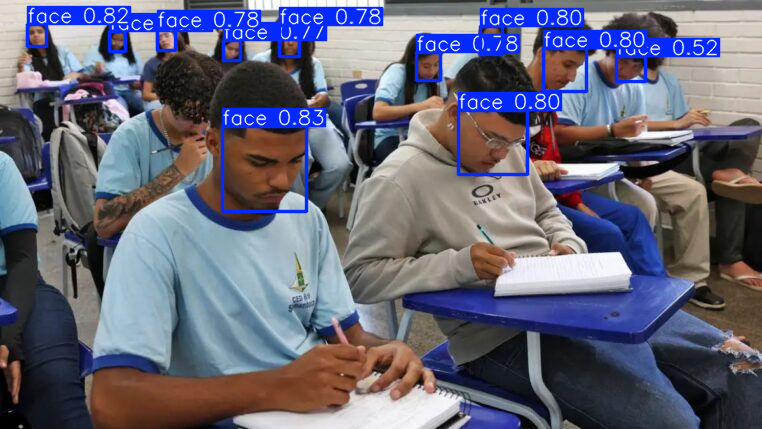

In [22]:
for resultado in resultados:
    # O .plot() desenha as caixas delimitadoras automáticas nos rostos detectados
    imagem_com_caixas = resultado.plot()

    # Exibe na tela do notebook
    cv2_imshow(imagem_com_caixas)

Validação com o WIDER FACE

In [23]:
caminho_melhores_pesos = '/content/drive/MyDrive/FOCA_IA/models/yolov8_nano_foca_v4_AdamW/weights/best.pt'
model = YOLO(caminho_melhores_pesos)

In [24]:
print("Iniciando a validação do modelo treinado com o WIDER FACE")
# O YOLO vai salvar os gráficos e imagens de teste automaticamente
resultados_val = model.val(data='/content/data_foca.yaml')

Iniciando a validação do modelo treinado com o WIDER FACE
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.3 ms, read: 285.5±167.2 MB/s, size: 112.4 KB)
val: Scanning /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val/labels... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226 489.3it/s 6.6s
val: /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val/images/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━

In [25]:
print("\n==================================================")
print("Métricas da validação")
print("==================================================")
print(f"Precision (Precisão): {resultados_val.box.mp:.4f} (Quantos dos rostos detectados eram realmente rostos)")
print(f"Recall (Sensibilidade): {resultados_val.box.mr:.4f} (Quantos dos rostos totais o modelo conseguiu achar)")
print(f"mAP50: {resultados_val.box.map50:.4f} (Quanto mais perto de 1.0, melhor)")
print(f"mAP50-95: {resultados_val.box.map:.4f}")
print("==================================================\n")


Métricas da validação
Precision (Precisão): 0.8600 (Quantos dos rostos detectados eram realmente rostos)
Recall (Sensibilidade): 0.6310 (Quantos dos rostos totais o modelo conseguiu achar)
mAP50: 0.7028 (Quanto mais perto de 1.0, melhor)
mAP50-95: 0.3820



Os resultados visuais foram salvos em: /content/runs/detect/val

Visualizando uma amostra das predições do modelo na validação:


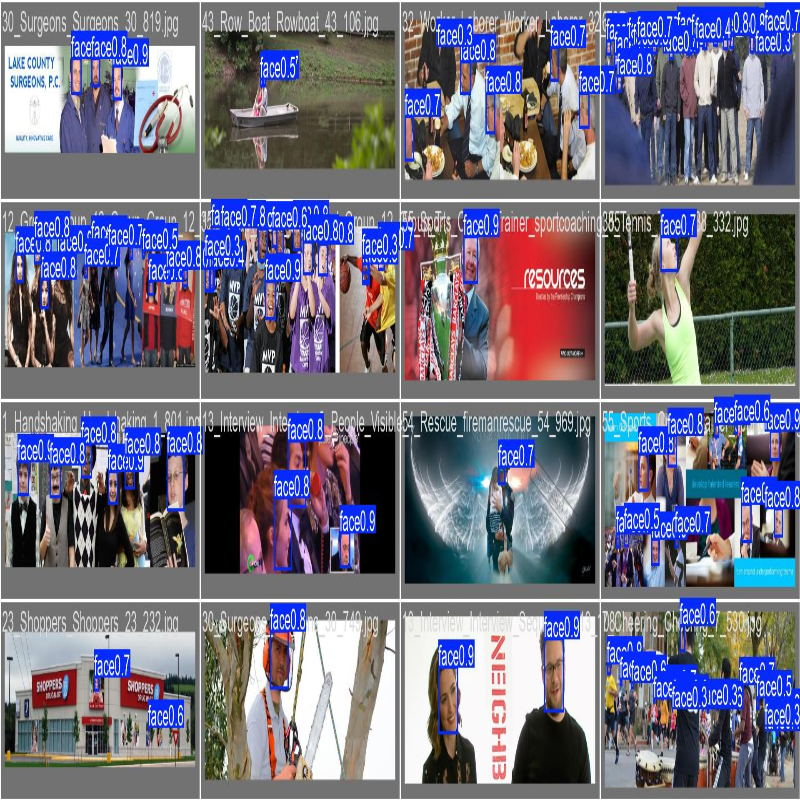

In [ ]:
# O YOLO cria imagens chamadas 'val_batchX_pred.jpg' mostrando as previsões lado a lado
# busca onde ele salvou os resultados
pasta_resultados = resultados_val.save_dir
print(f"Os resultados visuais foram salvos em: {pasta_resultados}")

# Vamos exibir o primeiro lote de imagens de validação na tela para você ver os rostos quadradinhos
imagem_predicoes = os.path.join(pasta_resultados, 'val_batch0_pred.jpg')

if os.path.exists(imagem_predicoes):
    print("\nVisualizando uma amostra das predições do modelo na validação:")
    img = cv2.imread(imagem_predicoes)
    img_redimensionada = cv2.resize(img, (800, 800))
    cv2_imshow(img_redimensionada)
else:
    print("Não foi possível carregar o mosaico de fotos 'val_batch0_pred.jpg'. Verifique a pasta de resultados.")